# Multi Layer Perceptron (MLP)

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Parameters

In [3]:
l1 = 1
l2 = 1

In [4]:
def forward_kinematics(x):
    theta1 = x[:,0]
    theta2 = x[:,1]

    px = l1*np.cos(theta1)+l2*np.cos(theta1+theta2)
    py = l1*np.sin(theta1)+l2*np.sin(theta1+theta2)
    
    p = np.array([px, py]).T

    return p

## Mixed Dataset

In [5]:
number_of_samples = 10000
np.random.seed(11)
theta_values = np.random.uniform(0, 2*np.pi, (number_of_samples,2))

p_values = forward_kinematics(theta_values)

df = pd.DataFrame(np.c_[theta_values, p_values], 
                  columns = [r'$\theta_1$', r'$\theta_2$', r'$p_x$', r'$p_y$'])

In [6]:
df

,$\theta_1$,$\theta_2$,$p_x$,$p_y$
0,1.132668,0.122367,0.734786,1.856107
1,2.910488,4.554894,-0.594521,1.154494
2,2.640217,3.050028,-0.047621,-0.078169
3,0.080304,3.062246,-0.003222,0.079260
4,5.917546,5.345703,1.198385,-1.321935
...,...,...,...,...
9995,5.734915,3.836813,-0.135795,-0.667634
9996,4.942600,5.611867,-0.198758,-1.877898
9997,3.065000,3.001630,-0.020425,-0.138349
9998,4.290085,1.231168,0.313641,-1.602468


In [7]:
X = p_values

theta1 = theta_values[:,0]
theta2 = theta_values[:,1]

Y = np.column_stack([
    np.sin(theta1),
    np.cos(theta1),
    np.sin(theta2),
    np.cos(theta2)
])

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer((2,)),
    tf.keras.layers.Dense(5, activation='relu'),
    tf.keras.layers.Dense(5, activation='relu'),
    tf.keras.layers.Dense(4, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics = ['mse', 'mae'])

history = model.fit(X_train,Y_train, epochs=200)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5109 - mae: 0.6318 - mse: 0.5109
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4427 - mae: 0.5887 - mse: 0.4427
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4063 - mae: 0.5593 - mse: 0.4063
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3337 - mae: 0.4888 - mse: 0.3337
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2924 - mae: 0.4402 - mse: 0.2924
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2781 - mae: 0.4241 - mse: 0.2781
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2711 - mae: 0.4156 - mse: 0.2711
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2668 - mae: 0.4099 - mse: 0.2668
Epoch 9/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2638 - mae: 0.4056 - mse: 0.2638
Epoch 10/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2616 - mae: 0.4023 - mse: 0.2616
Epoch 11/200
250/250 ━━━━━━━━━━━━━━━━━━

In [9]:
model.evaluate(X_test, Y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2476 - mae: 0.3722 - mse: 0.2476


[0.2475862205028534, 0.2475862205028534, 0.3722059428691864]

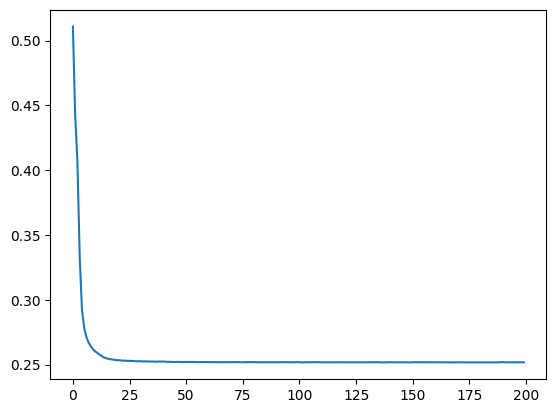

In [10]:
plt.plot(history.history['loss'])

### Prediction for Mixed Dataset

In [11]:
def position_error(px, py, theta1, theta2):

    px_pred = l1*np.cos(theta1) + l2*np.cos(theta1+theta2)
    py_pred = l1*np.sin(theta1) + l2*np.sin(theta1+theta2)

    error = np.sqrt((px - px_pred)**2 + (py - py_pred)**2)

    print("Predicted end effector:", px_pred, py_pred)
    print("True end effector:", px, py)
    print("Position error:", error)

    return error

def predict_angles(px, py):

    sample = np.array([[px, py]])

    pred = model.predict(sample, verbose=0)

    theta1 = np.arctan2(pred[0,0], pred[0,1])
    theta2 = np.arctan2(pred[0,2], pred[0,3])

    theta1_deg = np.degrees(theta1)
    theta2_deg = np.degrees(theta2)

    print("θ1 =", theta1_deg, "°")
    print("θ2 =", theta2_deg, "°")

    position_error(px, py, theta1, theta2)

In [12]:
predict_angles(-1, -1)

θ1 = -136.84875 °
θ2 = 177.64467 °
Predicted end effector: 0.027490675 -0.030559778
True end effector: -1 -1
Position error: 1.4126399


## Single Branch Generation

In [13]:
def inverse_kinematics(end_effector_values):
    px_values = end_effector_values[:,0]
    py_values = end_effector_values[:,1]

    phi = np.arctan2(px_values, py_values)

    pxsppys = np.square(px_values) + np.square(py_values)

    numerator = pxsppys + l1**2-l2**2
    denominator = 2*l1*np.sqrt(pxsppys)

    a = np.divide(numerator, denominator)

    theta1_first = np.arcsin(a) - phi
    theta1_second = np.pi - np.arcsin(a) - phi

    num1 = py_values-l1*np.sin(theta1_first)
    den1 = px_values-l1*np.cos(theta1_first)
    theta2_first = np.arctan2(num1,den1) - theta1_first

    num2 = py_values-l1*np.sin(theta1_second)
    den2 = px_values-l1*np.cos(theta1_second)
    theta2_second = np.arctan2(num2,den2) - theta1_second

    return np.array([theta1_first, theta2_first]).T, np.array([theta1_second, theta2_second]).T


### Elbow Up

In [14]:
pxpy = df.iloc[:,-2:].values
th1th2 = inverse_kinematics(pxpy)[0]
X2 = pxpy
Y2 = np.array([np.sin(th1th2[:,0]), np.cos(th1th2[:,0]), np.sin(th1th2[:,1]), np.cos(th1th2[:,1])]).T
X2_train, X2_test, Y2_train, Y2_test = train_test_split(
    X2, Y2, test_size=0.2, random_state=42
)

In [15]:
model2 = tf.keras.Sequential([
    tf.keras.layers.InputLayer((2,)),
    tf.keras.layers.Dense(5, activation='relu'),
    tf.keras.layers.Dense(5, activation='relu'),
    tf.keras.layers.Dense(4, activation='linear')
])

model2.compile(optimizer='adam', loss='mse', metrics = ['mse', 'mae'])

model2.fit(X2_train, Y2_train, epochs = 100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3214 - mae: 0.4839 - mse: 0.3214
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1976 - mae: 0.3684 - mse: 0.1976
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1513 - mae: 0.3196 - mse: 0.1513
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1210 - mae: 0.2861 - mse: 0.1210
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1006 - mae: 0.2551 - mse: 0.1006
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0892 - mae: 0.2314 - mse: 0.0892
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0833 - mae: 0.2201 - mse: 0.0833
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0802 - mae: 0.2149 - mse: 0.0802
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0779 - mae: 0.2114 - mse: 0.0779
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0753 - mae: 0.2065 - mse: 0.0753
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━

In [16]:
model2.evaluate(X2_test, Y2_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0325 - mae: 0.1326 - mse: 0.0325


[0.03254292532801628, 0.03254292532801628, 0.1326015442609787]

In [17]:
def position_error_1(px, py, theta1, theta2):

    px_pred = l1*np.cos(theta1) + l2*np.cos(theta1+theta2)
    py_pred = l1*np.sin(theta1) + l2*np.sin(theta1+theta2)

    error = np.sqrt((px - px_pred)**2 + (py - py_pred)**2)

    print("Predicted end effector:", px_pred, py_pred)
    print("True end effector:", px, py)
    print("Position error:", error)

    return error

def predict_angles_1(px, py):

    sample = np.array([[px, py]])

    pred = model2.predict(sample, verbose=0)

    theta1 = np.arctan2(pred[0,0], pred[0,1])
    theta2 = np.arctan2(pred[0,2], pred[0,3])

    theta1_deg = np.degrees(theta1)
    theta2_deg = np.degrees(theta2)

    print("θ1 =", theta1_deg, "°")
    print("θ2 =", theta2_deg, "°")

    position_error_1(px, py, theta1, theta2)

In [18]:
predict_angles_1(-1,-1)

θ1 = -170.85223 °
θ2 = 85.03568 °
Predicted end effector: -0.91433185 -1.1563165
True end effector: -1 -1
Position error: 0.17825231


### Elbow down

In [19]:
pxpy = df.iloc[:,-2:].values
th1th2 = inverse_kinematics(pxpy)[1]
X3 = pxpy
Y3 = np.array([np.sin(th1th2[:,0]), np.cos(th1th2[:,0]), np.sin(th1th2[:,1]), np.cos(th1th2[:,1])]).T
X3_train, X3_test, Y3_train, Y3_test = train_test_split(
    X3, Y3, test_size=0.2, random_state=42
)


In [20]:
model3 = tf.keras.Sequential([
    tf.keras.layers.InputLayer((2,)),
    tf.keras.layers.Dense(5, activation='relu'),
    tf.keras.layers.Dense(5, activation='relu'),
    tf.keras.layers.Dense(4, activation='linear')
])

model3.compile(optimizer='adam', loss='mse', metrics = ['mse', 'mae'])

model3.fit(X3_train, Y3_train, epochs = 100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5548 - mae: 0.6470 - mse: 0.5548
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3222 - mae: 0.4843 - mse: 0.3222
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2332 - mae: 0.3996 - mse: 0.2332
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1990 - mae: 0.3645 - mse: 0.1990
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1569 - mae: 0.3192 - mse: 0.1569
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1192 - mae: 0.2777 - mse: 0.1192
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1059 - mae: 0.2606 - mse: 0.1059
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0983 - mae: 0.2505 - mse: 0.0983
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0928 - mae: 0.2425 - mse: 0.0928
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0881 - mae: 0.2348 - mse: 0.0881
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━

In [21]:
model3.evaluate(X3_test, Y3_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0444 - mae: 0.1561 - mse: 0.0444


[0.044422030448913574, 0.044422030448913574, 0.15606652200222015]

In [22]:
def position_error_2(px, py, theta1, theta2):

    px_pred = l1*np.cos(theta1) + l2*np.cos(theta1+theta2)
    py_pred = l1*np.sin(theta1) + l2*np.sin(theta1+theta2)

    error = np.sqrt((px - px_pred)**2 + (py - py_pred)**2)

    print("Predicted end effector:", px_pred, py_pred)
    print("True end effector:", px, py)
    print("Position error:", error)

    return error

def predict_angles_2(px, py):

    sample = np.array([[px, py]])

    pred = model3.predict(sample, verbose=0)

    theta1 = np.arctan2(pred[0,0], pred[0,1])
    theta2 = np.arctan2(pred[0,2], pred[0,3])

    theta1_deg = np.degrees(theta1)
    theta2_deg = np.degrees(theta2)

    print("θ1 =", theta1_deg, "°")
    print("θ2 =", theta2_deg, "°")

    position_error_2(px, py, theta1, theta2)

In [23]:
predict_angles_2(-1, -1)

θ1 = -95.1138 °
θ2 = -93.6118 °
Predicted end effector: -1.0775604 -0.8443169
True end effector: -1 -1
Position error: 0.17393346
